Model Development Steps
Step 1: Load Data

In [4]:
import pandas as pd

data = pd.read_csv('../data/crop_yield_data.csv')
data.head()

,Region,Crop_Type,Temperature,Rainfall,Pesticide_Use,Yield,Soil_Moisture,Humidity,Solar_Radiation,Wind_Speed,Previous_Crop,Fertilizer_Residuals,Pest_Infestation_Severity,Disease_Presence,Pesticide_Effectiveness,Monsoon_Delay,Flood_Occurrence,Temperature_Extremes,Year
0,Uttar Pradesh,Soybean,31.763070,778.002361,359.708383,5998.662438,31.369864,52.229486,7.583216,6.890118,Wheat,256.303736,2.864568,1,93.056597,21.745672,1,0,2023
1,Tamil Nadu,Soybean,30.569374,1149.206824,269.359776,4483.037922,17.620807,64.135284,6.527483,1.230861,Maize,85.680463,7.638849,0,83.057594,8.227735,1,1,2023
2,Gujarat,Soybean,24.348558,477.338673,265.954295,5806.244894,6.009793,82.902538,6.358896,5.399473,Wheat,127.385498,2.864568,1,94.963469,5.542860,0,1,2023
3,Odisha,Soybean,27.490267,1457.484248,394.745101,2915.854696,15.385847,86.514335,4.971706,15.368421,Sugarcane,192.276745,0.954856,1,88.840842,2.508540,1,0,2023
4,Haryana,Sugarcane,31.513690,963.947870,221.780831,5107.170484,28.885015,74.373795,3.006422,17.700306,Maize,111.498150,1.909712,1,85.715361,3.094125,1,0,2023


Step 2: Preprocess

In [11]:
data.describe()

,Temperature,Rainfall,Pesticide_Use,Yield,Soil_Moisture,Humidity,Solar_Radiation,Wind_Speed,Fertilizer_Residuals,Pest_Infestation_Severity,Disease_Presence,Pesticide_Effectiveness,Monsoon_Delay,Flood_Occurrence,Temperature_Extremes,Year
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.00000,7000.000000,7000.000000,7000.00000,7000.000000,7000.000000
mean,30.107227,884.135477,278.007348,3752.142526,19.797025,59.368025,5.426256,9.881063,171.329344,4.879621,0.48600,80.169582,10.357858,0.51400,0.487000,2020.000000
std,5.800092,347.191256,108.081378,1302.387946,8.712580,17.050791,1.436581,5.567604,72.297191,3.143889,0.49984,11.480671,6.079921,0.49984,0.499867,2.000143
min,19.775443,274.826503,90.554352,1458.657229,4.961801,30.014460,3.001215,0.001057,50.255575,0.000000,0.00000,60.004746,0.004344,0.00000,0.000000,2017.000000
25%,25.206040,585.344125,184.135264,2658.992173,12.088321,44.684263,4.178135,5.302024,111.488509,2.084042,0.00000,70.079985,4.994567,0.00000,0.000000,2018.000000
50%,30.141536,881.759940,276.474999,3687.372217,19.793916,58.926604,5.348535,9.915365,170.219962,4.774280,0.00000,80.501909,10.390576,1.00000,0.000000,2020.000000
75%,35.075868,1172.991822,365.973448,4884.322975,27.451994,74.228017,6.639511,14.475822,232.812214,7.404926,1.00000,89.788555,15.478996,1.00000,1.000000,2022.000000
max,41.235287,1598.583229,492.892891,6144.062644,36.220614,89.952438,7.987115,19.972346,299.908906,10.921726,1.00000,99.992669,21.957425,1.00000,1.000000,2023.000000


In [5]:
# Apply one-hot encoding to object type columns, excluding the target variable 'Yield'
object_cols = data.select_dtypes(include='object').columns
object_cols = object_cols.drop('Yield', errors='ignore') # Exclude 'Yield' if it exists

data = pd.get_dummies(data, columns=object_cols, drop_first=True)

# Drop rows with any missing values
data = data.dropna()

Step 3: Split Data

In [6]:
from sklearn.model_selection import train_test_split

X = data.drop('Yield', axis=1)
y = data['Yield']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Step 4: Train Model

In [7]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Step 5: Evaluate

In [8]:
from sklearn.metrics import mean_absolute_error, r2_score

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 131.67687334322076
R² Score: 0.9796264288941998


Step 6: Visualize

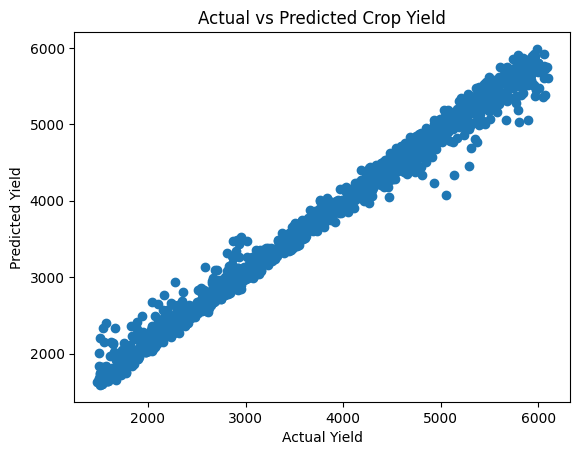

In [9]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")
plt.show()

In [10]:
# Save model
import pickle
pickle.dump(model, open('trained_model.pkl', 'wb'))